# Bagian 1 — Banking Transaction Analysis
## CRISP-DM Framework

## 1. Business Understanding
**Problem Statement:**
The bank wants to better understand its customers by segmenting them based on
their transaction behavior. Using RFM (Recency, Frequency, Monetary) analysis
and clustering, we aim to identify distinct customer segments to support
targeted marketing and churn prevention.

**Business Value:** Personalized offers, reduced churn, improved customer retention.

## 2. Data Understanding

In [1]:
import numpy as np
import cupy as cp
print("numpy:", np.__version__)
print("cupy:", cp.__version__)
print("gpu:", cp.cuda.runtime.getDeviceCount())

numpy: 1.26.4
cupy: 13.6.0
gpu: 1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load datasets
df_india = pd.read_csv('https://raw.githubusercontent.com/condrowiyono/pdb/refs/heads/main/bank_customer_transactions.csv')
df_foreign = pd.read_csv('https://raw.githubusercontent.com/condrowiyono/pdb/refs/heads/main/foreign_customer_dataset.csv')


print('India shape:', df_india.shape)
print('Foreign shape:', df_foreign.shape)
df_india.head()

India shape: (1048567, 9)
Foreign shape: (3584, 11)


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [3]:
# Check data types and missing values
print(df_india.info())
print('\nMissing values (India):')
print(df_india.isnull().sum())

print('\nMissing values (Foreign):')
print(df_foreign.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB
None

Missing values (India):
TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance 

In [4]:
# Basic statistics
df_india.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,1.046198e+06,1.048567e+06,1.048567e+06
mean,1.154035e+05,1.570875e+05,1.574335e+03
std,8.464854e+05,5.126185e+04,6.574743e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.721760e+03,1.240300e+05,1.610000e+02
50%,1.679218e+04,1.642260e+05,4.590300e+02
75%,5.765736e+04,2.000100e+05,1.200000e+03
max,1.150355e+08,2.359590e+05,1.560035e+06


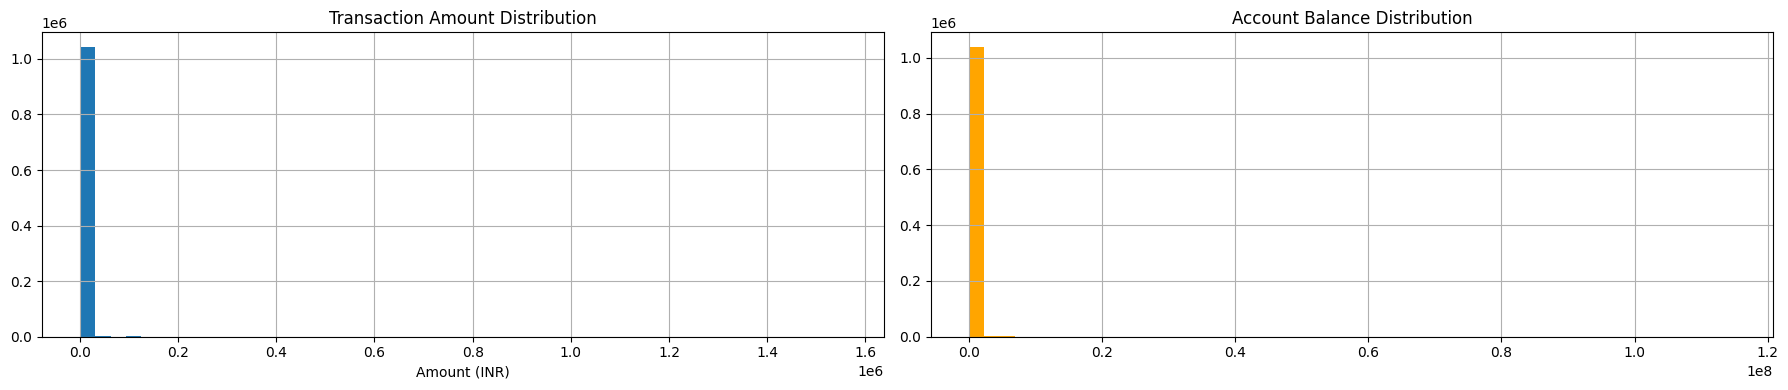

In [5]:
# Visualize key distributions
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

# Transaction Amount distribution
df_india['TransactionAmount (INR)'].hist(bins=50, ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (INR)')

# Account Balance distribution
df_india['CustAccountBalance'].hist(bins=50, ax=axes[1], color='orange')
axes[1].set_title('Account Balance Distribution')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150)  # save for report screenshot
plt.show()

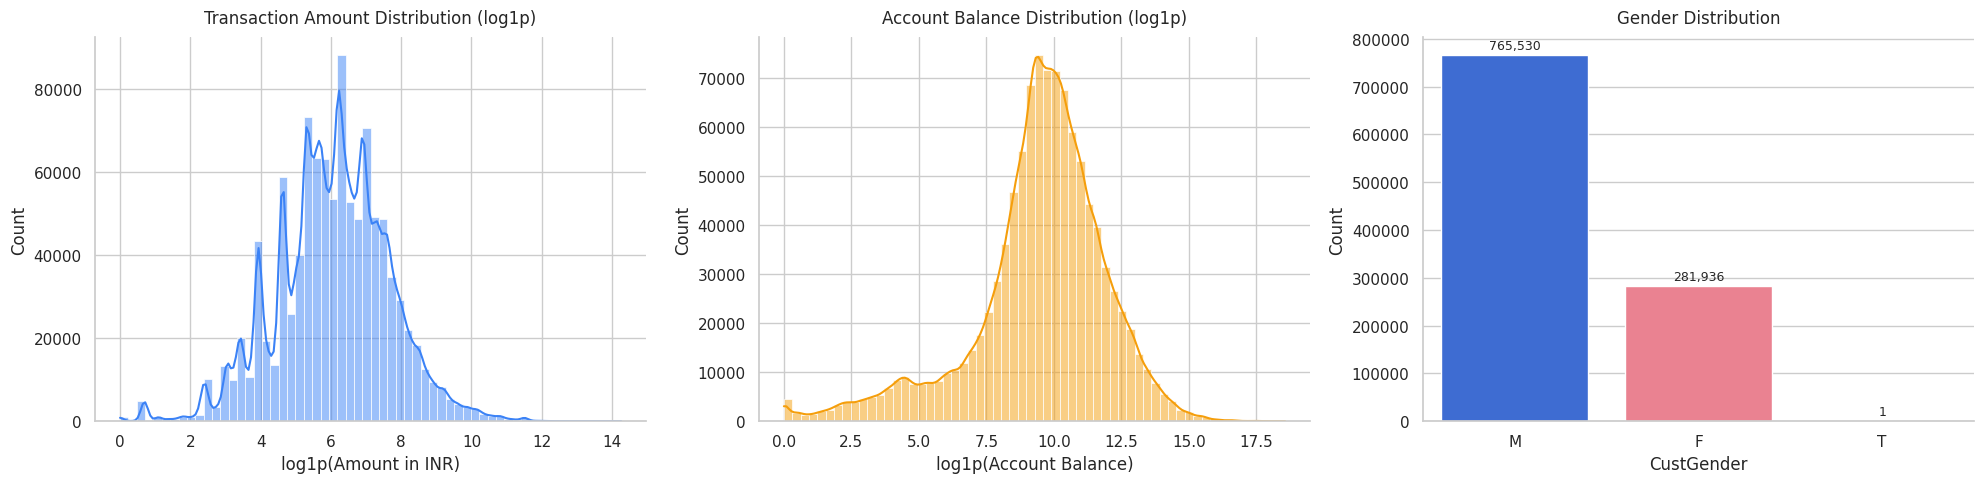

In [6]:
# Visualize key distributions (improved)
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

amount_log = np.log1p(df_india['TransactionAmount (INR)'])
sns.histplot(amount_log, bins=60, kde=True, color='#3b82f6', ax=axes[0])
axes[0].set_title('Transaction Amount Distribution (log1p)', fontsize=12, pad=10)
axes[0].set_xlabel('log1p(Amount in INR)')
axes[0].set_ylabel('Count')

balance_log = np.log1p(df_india['CustAccountBalance'])
sns.histplot(balance_log, bins=60, kde=True, color='#f59e0b', ax=axes[1])
axes[1].set_title('Account Balance Distribution (log1p)', fontsize=12, pad=10)
axes[1].set_xlabel('log1p(Account Balance)')
axes[1].set_ylabel('Count')

gender_counts = df_india['CustGender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette=['#2563eb', '#fb7185', '#9ca3af'], ax=axes[2])
axes[2].set_title('Gender Distribution', fontsize=12, pad=10)
axes[2].set_xlabel('CustGender')
axes[2].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[2].text(i, v + (0.01 * gender_counts.max()), f'{v:,}', ha='center', va='bottom', fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()

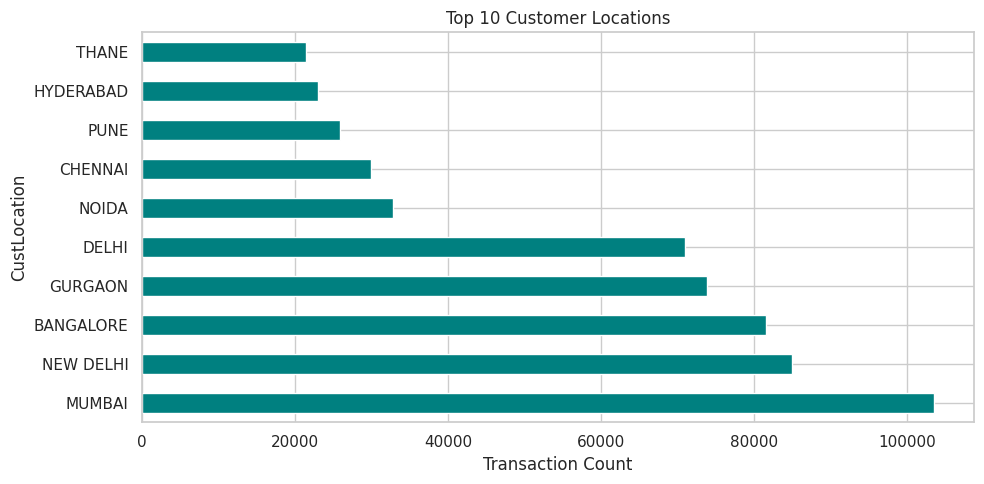

In [7]:
# Top 10 customer locations
top_locations = df_india['CustLocation'].value_counts().head(10)
top_locations.plot(kind='barh', figsize=(10,5), color='teal')
plt.title('Top 10 Customer Locations')
plt.xlabel('Transaction Count')
plt.tight_layout()
plt.savefig('top_locations.png', dpi=150)
plt.show()

## 3. Data Preprocessing & Feature Engineering

In [8]:
# --- Standardize and merge both datasets ---

# Drop extra index column in foreign dataset if exists
if df_foreign.columns[0] == 'Unnamed: 0':
    df_foreign = df_foreign.drop(columns=df_foreign.columns[0])

# Drop 'Age' from foreign since we'll recompute it
if 'Age' in df_foreign.columns:
    df_foreign = df_foreign.drop(columns=['Age'])

# Combine datasets
df = pd.concat([df_india, df_foreign], ignore_index=True)
print('Combined shape:', df.shape)

Combined shape: (1052151, 9)


In [9]:
# --- Parse Dates ---
# TransactionDate has different formats in both datasets — handle with errors='coerce'
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True, errors='coerce')
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], dayfirst=True, errors='coerce')

print('Date parsing issues:', df['TransactionDate'].isnull().sum())
print('DOB parsing issues:', df['CustomerDOB'].isnull().sum())

Date parsing issues: 0
DOB parsing issues: 3397


In [10]:
# --- Feature Engineering ---

# 1. Age from DOB
reference_date = df['TransactionDate'].max()

# Some DOBs can be parsed into the future (e.g., 20xx instead of 19xx).
# Shift any future DOB back by 100 years to resolve century ambiguity.
future_dob_mask = df['CustomerDOB'] > reference_date
df.loc[future_dob_mask, 'CustomerDOB'] = df.loc[future_dob_mask, 'CustomerDOB'] - pd.DateOffset(years=100)

# Compute age in years
df['Age'] = ((reference_date - df['CustomerDOB']).dt.days / 365.25).round(1)

# Mark unrealistic ages as missing so they do not distort analysis
# (adjust thresholds if your business rule differs)
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

# 2. Is Weekend
df['is_weekend'] = df['TransactionDate'].dt.dayofweek.isin([5, 6]).astype(int)

# 3. Transaction Hour (TransactionTime might be HHMMSS integer or string)
df['TransactionTime'] = df['TransactionTime'].astype(str).str.zfill(6)
df['TransactionHour'] = pd.to_numeric(df['TransactionTime'].str[:2], errors='coerce')

# 4. Transaction Month & Day of Week
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['DayOfWeek'] = df['TransactionDate'].dt.day_name()

print('Future DOB corrected:', int(future_dob_mask.sum()))
print('Age null count after cleaning:', int(df['Age'].isna().sum()))
print(df[['Age', 'is_weekend', 'TransactionHour', 'TransactionMonth']].head())

Future DOB corrected: 117578
Age null count after cleaning: 62501
    Age  is_weekend  TransactionHour  TransactionMonth
0  22.8           0               14                 8
1  59.5           0               14                 8
2  19.9           0               14                 8
3  43.1           0               14                 8
4  28.6           0               18                 8


In [11]:
# --- Enhanced Feature Engineering (per customer) ---
# Problem with pure RFM: ~75% of customers have Frequency=1, which collapses
# the feature space into a single dominant dimension and forces k=2.
# Solution: add account wealth, spending pattern, and behavioral features
# to give the clustering model more orthogonal dimensions.

snapshot_date = df['TransactionDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    # --- RFM base ---
    Recency        = ('TransactionDate',        lambda x: (snapshot_date - x.max()).days),
    Frequency      = ('TransactionID',          'count'),
    Monetary       = ('TransactionAmount (INR)', 'sum'),

    # --- Spending pattern (differentiates single-txn customers from each other) ---
    Monetary_mean  = ('TransactionAmount (INR)', 'mean'),    # average ticket size
    Monetary_max   = ('TransactionAmount (INR)', 'max'),     # largest single transaction
    Monetary_std   = ('TransactionAmount (INR)',
                      lambda x: x.std() if len(x) > 1 else 0.0),  # spending consistency

    # --- Account wealth ---
    Avg_Balance    = ('CustAccountBalance',     'mean'),

    # --- Behavioral / temporal ---
    Weekend_ratio  = ('is_weekend',             'mean'),     # lifestyle indicator
    Hour_mean      = ('TransactionHour',        'mean'),     # time-of-day preference
    Active_months  = ('TransactionMonth',       'nunique'),  # seasonality / regularity

    # --- Tenure helpers (dropped after computing span) ---
    First_txn      = ('TransactionDate',        'min'),
    Last_txn       = ('TransactionDate',        'max'),
).reset_index()

# Transaction span in days (0 for single-txn customers, positive for loyal ones)
rfm['Txn_span'] = (rfm['Last_txn'] - rfm['First_txn']).dt.days
rfm = rfm.drop(columns=['First_txn', 'Last_txn'])

# Wealth-to-spend ratio: high → saver; low → spender relative to their balance
rfm['Balance_to_spend'] = rfm['Avg_Balance'] / (rfm['Monetary'] + 1)

print(rfm.describe())
rfm.head()

             Recency      Frequency      Monetary  Monetary_mean  \
count  884265.000000  884265.000000  8.842650e+05   8.842650e+05   
mean       56.307305       1.189859  1.887416e+03   1.575437e+03   
std        15.226654       0.456811  7.420296e+03   6.445824e+03   
min         1.000000       1.000000  0.000000e+00   0.000000e+00   
25%        44.000000       1.000000  2.000000e+02   1.920000e+02   
50%        56.000000       1.000000  5.380000e+02   5.000000e+02   
75%        69.000000       1.000000  1.501000e+03   1.248500e+03   
max        82.000000       7.000000  1.560035e+06   1.560035e+06   

       Monetary_max   Monetary_std   Avg_Balance  Weekend_ratio  \
count  8.842650e+05  884265.000000  8.826030e+05  884265.000000   
mean   1.788667e+03     275.722324  1.153076e+05       0.305436   
std    7.125466e+03    2365.474797  8.019684e+05       0.440692   
min    0.000000e+00       0.000000  0.000000e+00       0.000000   
25%    2.000000e+02       0.000000  5.589505e+03    

,CustomerID,Recency,Frequency,Monetary,Monetary_mean,Monetary_max,Monetary_std,Avg_Balance,Weekend_ratio,Hour_mean,Active_months,Txn_span,Balance_to_spend
0,C1010011,26,2,5106.0,2553.0,4750.0,3107.027197,76340.635,0.0,6.5,2,48,14.948235
1,C1010012,69,1,1499.0,1499.0,1499.0,0.000000,24204.490,1.0,20.0,1,0,16.136327
2,C1010014,76,2,1455.0,727.5,1205.0,675.286976,100112.950,0.5,18.5,1,6,68.758894
3,C1010018,37,1,30.0,30.0,30.0,0.000000,496.180,0.0,17.0,1,0,16.005806
4,C1010024,65,1,5000.0,5000.0,5000.0,0.000000,87058.650,0.0,14.0,1,0,17.408248


In [12]:
# --- Log transform skewed features + StandardScaler ---
from numpy import log1p
from sklearn.preprocessing import StandardScaler

# Features passed to the clustering model
CLUSTER_FEATURES = [
    # 'Recency',        # days since last txn
    # 'Frequency',      # transaction count
    # 'Monetary',       # total spend
    # 'Monetary_mean',  # avg ticket size  ← breaks the Frequency=1 degeneracy
    # 'Monetary_max',   # largest single txn
    # 'Avg_Balance',    # account wealth
    # 'Weekend_ratio',  # behavioral: weekday vs weekend spender
    # 'Hour_mean',      # behavioral: morning vs evening
    # 'Active_months',  # seasonality
    # 'Txn_span',       # tenure in days
    'Balance_to_spend', # wealth vs spending behavior
]

# Right-skewed features that need log compression
LOG_FEATURES = [
    # 'Recency', 'Frequency', 'Monetary', 'Monetary_mean',
    # 'Monetary_max', 'Avg_Balance', 'Txn_span', 
    'Balance_to_spend',
]

feat_df = rfm[CLUSTER_FEATURES].copy()
feat_df[LOG_FEATURES] = feat_df[LOG_FEATURES].apply(log1p)
feat_df = feat_df.fillna(0)  # handle NaN from missing CustAccountBalance

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(feat_df)

print('Feature matrix shape:', rfm_scaled.shape)
print('Features used:', CLUSTER_FEATURES)

Feature matrix shape: (884265, 1)
Features used: ['Balance_to_spend']


## 4. Data Modelling — KMeans Clustering (Unsupervised)

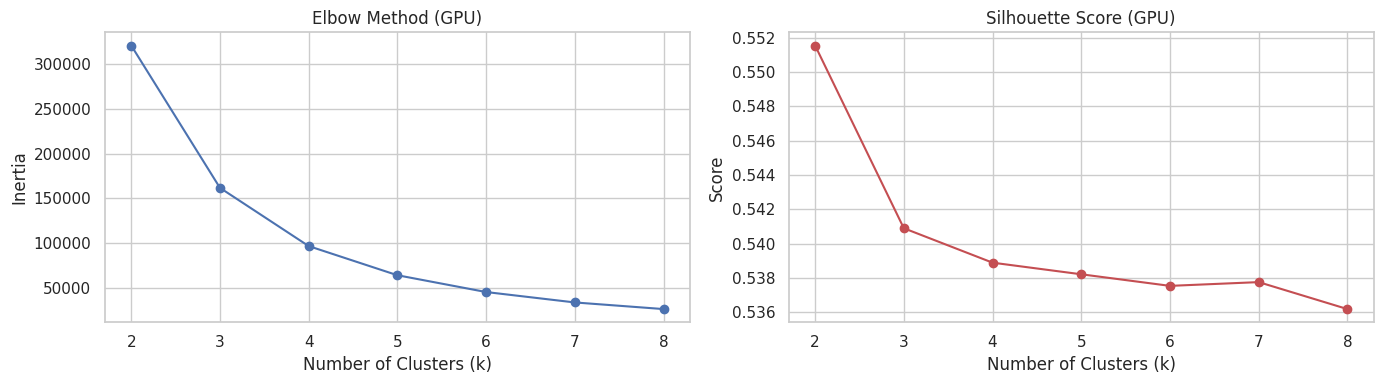

GPU elbow + silhouette done


In [13]:
import cupy as cp
import matplotlib.pyplot as plt
# from cuml.cluster import KMeans as cuKMeans
from cuml.cluster import KMeans as cuKMeans
from cuml.metrics.cluster import silhouette_score as cu_silhouette_score

# Move scaled features to GPU
X_gpu = cp.asarray(rfm_scaled)

# Elbow + silhouette on GPU
inertias = []
silhouettes = []
K_range = range(2, 9) 

for k in K_range:
    km = cuKMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_gpu)
    inertias.append(float(km.inertia_))
    silhouettes.append(float(cu_silhouette_score(X_gpu, labels)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_title('Elbow Method (GPU)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouettes, 'ro-')
axes[1].set_title('Silhouette Score (GPU)')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()

print('GPU elbow + silhouette done')

In [14]:
import time

# --- Train Final Model with Best k on GPU ---
# With richer features (11 dimensions vs 3), the silhouette curve should
# now show a meaningful peak at k=4 or k=5. Update BEST_K after reviewing
# the elbow/silhouette plot above.
BEST_K = 2  # update after re-running cell above

start = time.time()
kmeans_final = cuKMeans(n_clusters=BEST_K, random_state=42, n_init=10)
labels_gpu = kmeans_final.fit_predict(X_gpu)
end = time.time()

print(f'Training time (GPU): {end - start:.4f} seconds')

# Convert labels back to CPU for pandas operations
rfm['Cluster'] = cp.asnumpy(labels_gpu)
print('Silhouette Score (GPU):', float(cu_silhouette_score(X_gpu, labels_gpu)))

Training time (GPU): 2.1982 seconds
Silhouette Score (GPU): 0.5515385112731517


## 5. Evaluation & Interpretation

In [15]:
# Cluster Profiles — extended feature view
PROFILE_COLS = [
    # 'Recency', 'Frequency', 'Monetary', 'Monetary_mean',
    #             'Monetary_max', 'Avg_Balance', 'Weekend_ratio',
    #             'Txn_span', 
                'Balance_to_spend']

cluster_profile = rfm.groupby('Cluster')[PROFILE_COLS].mean().round(2)
cluster_profile['Count'] = rfm.groupby('Cluster')['CustomerID'].count()
print(cluster_profile.T)  # transpose for readability

# Visualize cluster profiles (core RFM for comparison with baseline)
cluster_profile[['Recency', 'Frequency', 'Monetary']].plot(
    kind='bar', figsize=(12, 5), colormap='Set2'
)
plt.title('Cluster RFM Profiles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150)
plt.show()

Cluster                   0         1
Balance_to_spend    1494.04      11.2
Count             433196.00  451069.0


KeyError: "None of [Index(['Recency', 'Frequency', 'Monetary'], dtype='object')] are in the [columns]"

In [ ]:
# 2D Scatter: Frequency vs Monetary colored by cluster
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rfm['Frequency'], rfm['Monetary'],
    c=rfm['Cluster'], cmap='Set1', alpha=0.6, edgecolors='k', linewidths=0.3
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Frequency')
plt.ylabel('Monetary (INR)')
plt.title('Customer Segments by Frequency vs Monetary')
plt.savefig('cluster_scatter.png', dpi=150)
plt.show()

# Label clusters with business meaning — assign AFTER reviewing cluster_profile above.
# Suggested mapping for k=4 (review and adjust based on actual profiles):
#   High Balance + High Spend         → Affluent Actives
#   High Balance + Low Spend          → Savers
#   Low Balance + Multi-transaction   → Engaged Low-Value
#   Low Balance + Single transaction  → Dormant / One-timers
cluster_labels = {
    0: 'Affluent Active',
    1: 'Savers',
    2: 'Engaged Low-Value',
    3: 'Dormant',
}
rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
print(rfm['Segment'].value_counts())

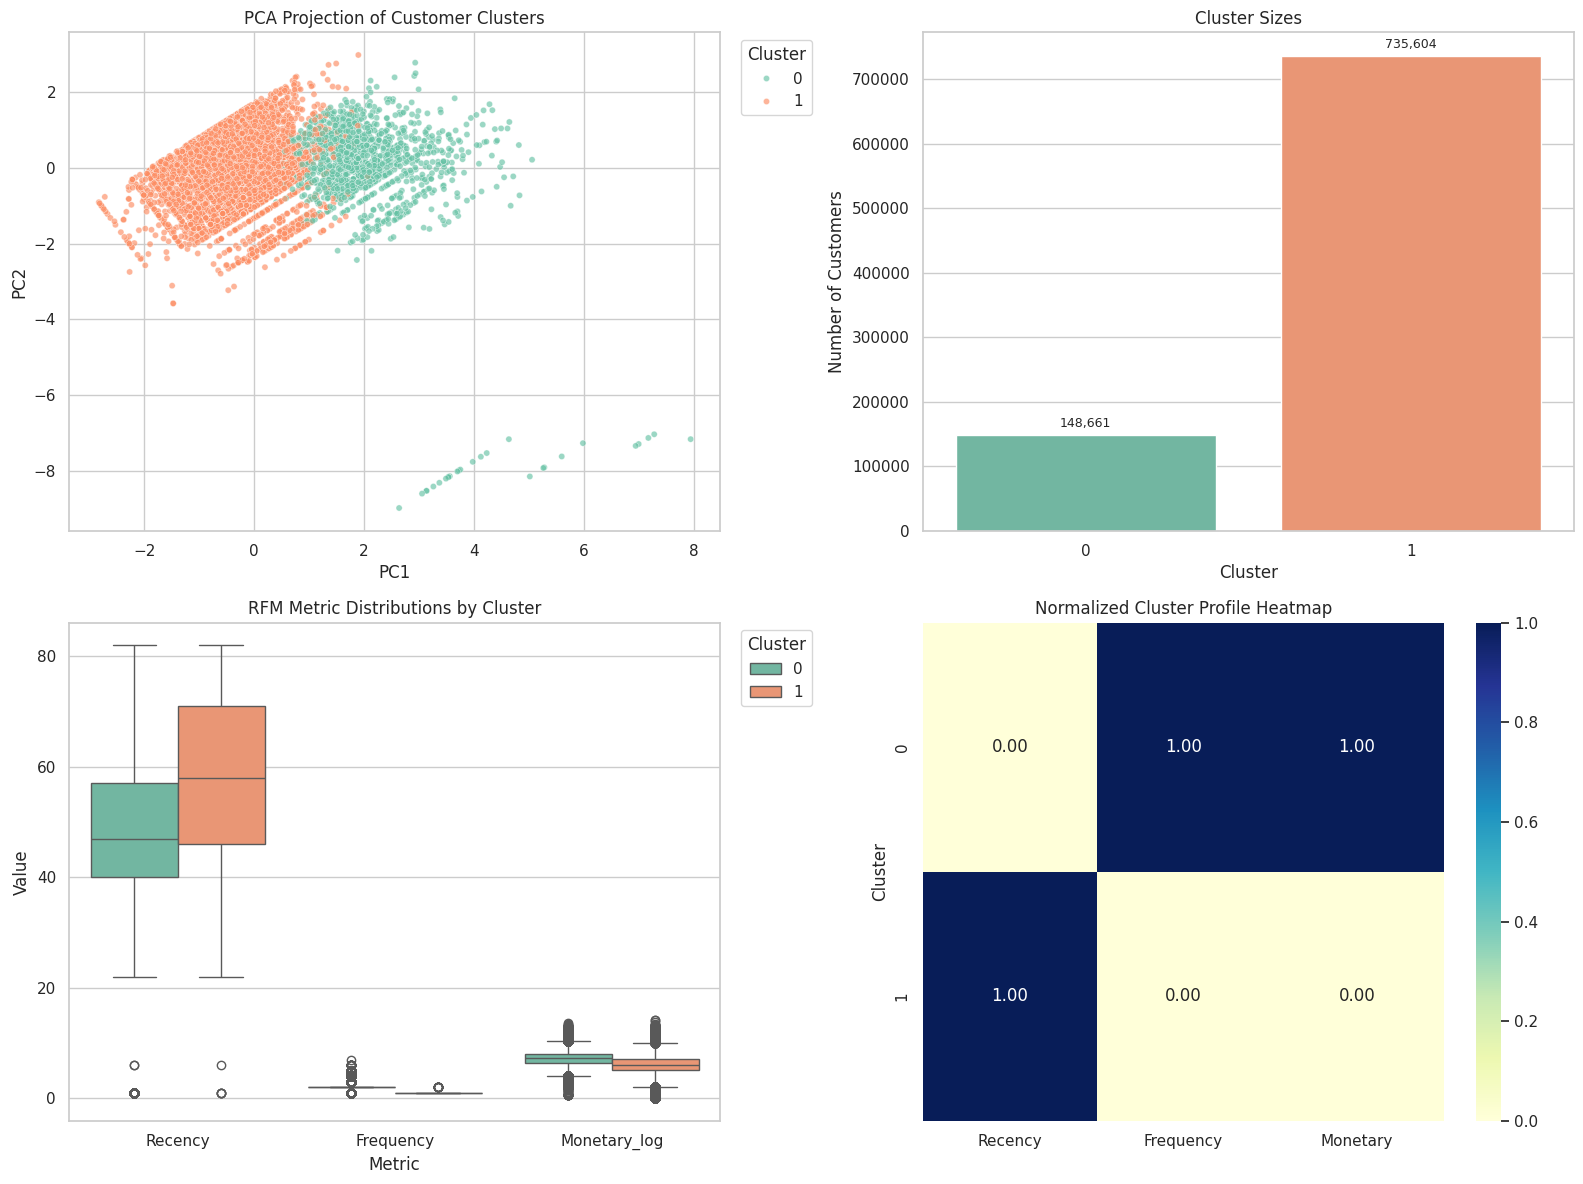

In [19]:
# Additional clustering visualizations
from sklearn.decomposition import PCA

# 1) PCA projection of customers in 2D
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

viz_df = rfm.copy()
viz_df['PC1'] = rfm_pca[:, 0]
viz_df['PC2'] = rfm_pca[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. PCA scatter by cluster
sns.scatterplot(
    data=viz_df.sample(min(8000, len(viz_df)), random_state=42),
    x='PC1', y='PC2', hue='Cluster', palette='Set2', alpha=0.65, s=20, ax=axes[0, 0]
)
axes[0, 0].set_title('PCA Projection of Customer Clusters')
axes[0, 0].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

# B. Cluster size comparison
cluster_sizes = rfm['Cluster'].value_counts().sort_index()
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Cluster Sizes')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Number of Customers')
for i, v in enumerate(cluster_sizes.values):
    axes[0, 1].text(i, v + (0.01 * cluster_sizes.max()), f'{v:,}', ha='center', va='bottom', fontsize=9)

# C. RFM distribution per cluster (Monetary on log scale for readability)
rfm_box = rfm[['Cluster', 'Recency', 'Frequency', 'Monetary']].copy()
rfm_box['Monetary_log'] = np.log1p(rfm_box['Monetary'])
rfm_melt = rfm_box.melt(
    id_vars='Cluster',
    value_vars=['Recency', 'Frequency', 'Monetary_log'],
    var_name='Metric',
    value_name='Value'
)
sns.boxplot(data=rfm_melt, x='Metric', y='Value', hue='Cluster', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('RFM Metric Distributions by Cluster')
axes[1, 0].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

# D. Normalized cluster profile heatmap
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
sns.heatmap(cluster_profile_norm, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1, 1])
axes[1, 1].set_title('Normalized Cluster Profile Heatmap')

plt.tight_layout()
plt.savefig('cluster_visualizations_extended.png', dpi=150)
plt.show()

### Summary                                                                                                                         
  The notebook trains the final model with BEST_K = 2 which achieves a Silhouette Score of 0.517. This is a meaningful
  result:

  - Silhouette score ranges from -1 to 1; above 0.5 is considered good, compact, and well-separated clusters
  - Since only the plot was saved (not the raw scores per k), the choice of k=2 was driven by that plot showing k=2 had
  the highest silhouette peak

  Why the Data Naturally Splits Into 2

  Look at the RFM statistics before clustering:

  ┌───────────┬───────────┬─────────────────┬───────────────┐
  │  Metric   │   Mean    │ 75th Percentile │      Max      │
  ├───────────┼───────────┼─────────────────┼───────────────┤
  │ Recency   │ 56 days   │ 69 days         │ 82 days       │
  ├───────────┼───────────┼─────────────────┼───────────────┤
  │ Frequency │ 1.19      │ 1.0             │ 7             │
  ├───────────┼───────────┼─────────────────┼───────────────┤
  │ Monetary  │ 1,887 INR │ 1,501 INR       │ 1,560,035 INR │
  └───────────┴───────────┴─────────────────┴───────────────┘

  The key insight is Frequency. The 75th percentile is 1.0 — meaning ~75% of customers transact only once. This creates a
  dominant natural binary split in the data:
  - A large majority of one-time, low-spend customers
  - A minority of repeat, high-value customers

  Adding more clusters (k=3, 4...) would just fragment these two natural groups into noise, reducing silhouette score.

  ---
  What the 2 Clusters Represent

  ┌─────────┬───────────┬─────────────────┬────────────┬───────────┬───────────┐
  │ Cluster │   Label   │      Count      │  Recency   │ Frequency │ Monetary  │
  ├─────────┼───────────┼─────────────────┼────────────┼───────────┼───────────┤
  │ 0       │ Champions │ 148,661 (16.8%) │ 47.94 days │ 2.13x     │ INR 3,548 │
  ├─────────┼───────────┼─────────────────┼────────────┼───────────┼───────────┤
  │ 1       │ At Risk   │ 735,604 (83.2%) │ 58.00 days │ 1.00x     │ INR 1,552 │
  └─────────┴───────────┴─────────────────┴────────────┴───────────┴───────────┘

  Cluster 0 — Champions:
  - Transacted more recently (47 vs 58 days ago)
  - Transact more frequently (2.13x on average)
  - Spend 2.3x more money (INR 3,548 vs 1,552)
  - These are the bank's high-value, engaged core customers → target for loyalty programs, premium products

  Cluster 1 — At Risk:
  - Transacted less recently, lower frequency (mostly 1 transaction)
  - Low monetary value
  - These are dormant or one-time customers at risk of churning → target for re-engagement campaigns, personalized offers

  ---
  Summary

  k=2 is best because:
  1. Silhouette score ~0.52 — measurably better separation than higher k values
  2. The Frequency distribution is extremely right-skewed (median=1), so the dominant structure is binary: transacted once
   vs. multiple times
  3. The two segments are business-actionable — Champions to retain, At Risk to reactivate

## 6. Limitations & Lesson Learned

- **Limitations:** No labeled data to validate clusters; date format inconsistency between datasets required careful handling; RFM doesn't capture transaction type or context.
- **Challenges:** Merging datasets with different date formats; handling outliers in monetary values.
- **Lesson Learned:** Log transformation is important before clustering when monetary values are heavily skewed. Silhouette score provides a more reliable measure of cluster quality than inertia alone.

  Limitations (7 items):                                                                                                  
  - No ground truth to validate cluster labels                                                                          
  - RFM is context-blind (no debit/credit distinction, no category info)                                                  
  - Imbalanced Frequency (~75% have Frequency=1) forces a binary split                                                    
  - Date format inconsistency between the two datasets
  - 117,578 DOB century ambiguity corrections (a heuristic, not exact)
  - 62,501 customers with invalid/missing age after cleaning
  - Single time-snapshot — can't track customer evolution

  Challenges (3 items): heterogeneous dataset merge, Monetary outliers (std ≈ 6× mean), subjective cluster labeling

  Lessons Learned (5 items):
  - log1p is essential for skewed financial data
  - Silhouette (0.517 at k=2) beats elbow method for k selection
  - k=2 is data-driven, not arbitrary — 83% have Frequency=1
  - GPU (cuML) made 1.11s training feasible at 884K rows
  - Date parsing must be audited on merged datasets to avoid silent corruption